In [30]:
# importing prority_retention customers 
import pandas as pd
df = pd.read_csv('/Users/prashantsinghchauhan/Downloads/GA_/Capstone/priority_retention.csv')
df.head()
df.shape

(2668, 9)

In [7]:
# Defining features X and target Y 
X = df[['MonthlyCharges', 'tenure', 'contract', 'InternetService']]
Y = df['churn']

In [8]:
# hot encoding categorical variables 

X_encoded = pd.get_dummies(X, columns = ['contract', 'InternetService'], drop_first= True)
X_encoded

,MonthlyCharges,tenure,contract_One year,contract_Two year
0,73.90,4,False,False
1,98.00,13,False,False
2,83.90,3,False,False
3,68.95,5,False,False
4,72.10,1,False,False
...,...,...,...,...
2663,99.15,64,False,False
2664,84.95,47,True,False
2665,94.05,7,True,False
2666,70.15,1,False,False


In [49]:
# Spliting & scaling the data set for testing and training 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 

# Spliting 
X_train, X_test , Y_train, Y_test = train_test_split(X_encoded, Y, test_size = 0.2, random_state = 42)

# Scaling 
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [50]:
# training and testing the model 

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

#training
model = LogisticRegression()
model.fit(X_train_scaled, Y_train)

#testing
Y_pred = model.predict(X_test_scaled)
# print(classification_report(Y_test, Y_pred, output_dict = True ))

df_report = pd.DataFrame(classification_report(Y_test, Y_pred, output_dict = True)).transpose()
df_report = df_report.round(2) 
df_report

,precision,recall,f1-score,support
No,0.69,0.65,0.67,278.00
Yes,0.64,0.69,0.67,256.00
accuracy,0.67,0.67,0.67,0.67
macro avg,0.67,0.67,0.67,534.00
weighted avg,0.67,0.67,0.67,534.00


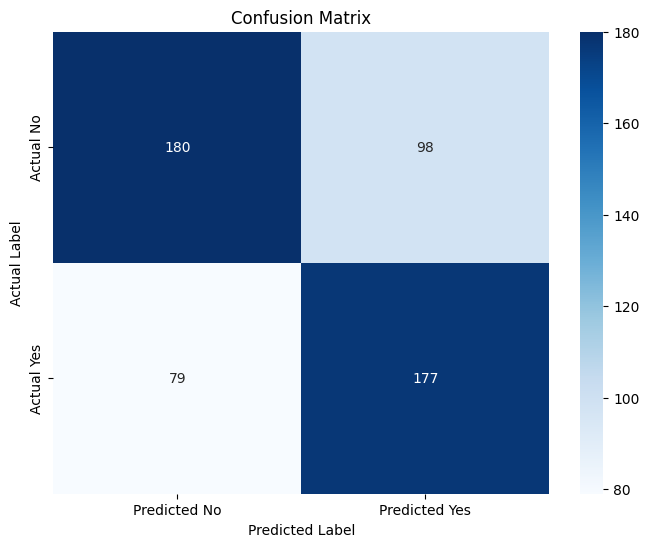

In [51]:
# Visualising the confusioin matrix 

cm = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()
